# AAPL Stock Data Preparation and Cleaning

This notebook performs data loading and cleaning for the AAPL stock price prediction project.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

## 1. Download AAPL Dataset

Prices are downloaded with `auto_adjust=True`, so the OHLC values are adjusted for stock splits and dividends. The date interval and adjustment behavior are explicit to keep the dataset reproducible.


In [2]:
# Download split-adjusted AAPL prices with explicit, reproducible settings
aapl = yf.download(
    "AAPL",
    start="2015-01-01",
    end="2025-01-01",
    auto_adjust=True,
    progress=False
)

# yfinance may return a MultiIndex even for one ticker.
if isinstance(aapl.columns, pd.MultiIndex):
    aapl.columns = aapl.columns.get_level_values(0)

aapl = aapl.sort_index()
print(aapl.columns)
aapl.head()


Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')


Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,24.192604,24.659506,23.754468,24.648441,212818400
2015-01-05,23.511059,24.042132,23.325184,23.962471,257142000
2015-01-06,23.513273,23.772171,23.152585,23.575232,263188400
2015-01-07,23.842974,23.942549,23.610629,23.721269,160423600
2015-01-08,24.759085,24.816618,24.053199,24.170479,237458000


## 2. Dataset Structure Review

In [3]:
# Display first five rows

aapl.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,24.192604,24.659506,23.754468,24.648441,212818400
2015-01-05,23.511059,24.042132,23.325184,23.962471,257142000
2015-01-06,23.513273,23.772171,23.152585,23.575232,263188400
2015-01-07,23.842974,23.942549,23.610629,23.721269,160423600
2015-01-08,24.759085,24.816618,24.053199,24.170479,237458000


In [4]:
# Display dataset dimensions

print("Dataset Shape:")
print(aapl.shape)

Dataset Shape:
(2516, 5)


In [5]:
# Display dataset information

aapl.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2516 entries, 2015-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2516 non-null   float64
 1   High    2516 non-null   float64
 2   Low     2516 non-null   float64
 3   Open    2516 non-null   float64
 4   Volume  2516 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 117.9 KB


In [6]:
# Display column names

print(aapl.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')


## 3. Missing Value Analysis

In [7]:
# Check missing values

missing_values = aapl.isnull().sum()

print(missing_values)

Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [8]:
# Remove missing values if any exist

aapl = aapl.dropna()

## 4. Duplicate Record Analysis

In [9]:
# Check duplicate rows

duplicates = aapl.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [10]:
# Remove duplicate records if found

aapl = aapl.drop_duplicates()

## 5. Data Type Validation

In [11]:
# Check data types

print(aapl.dtypes)

Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object


In [12]:
# Ensure date index is datetime format

aapl.index = pd.to_datetime(aapl.index)

print(type(aapl.index))

<class 'pandas.DatetimeIndex'>


## 6. Outlier Detection

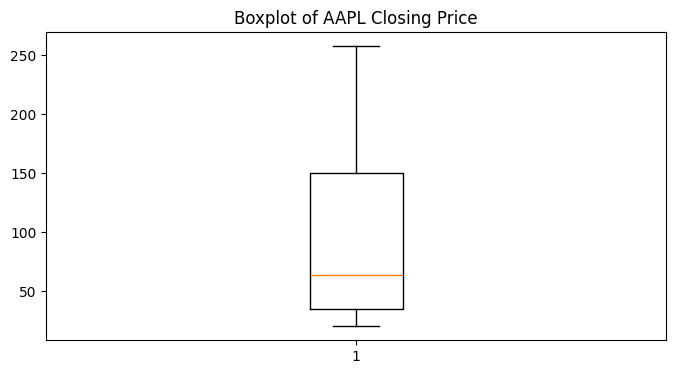

In [13]:
# Boxplot of Closing Price

plt.figure(figsize=(8,4))

plt.boxplot(aapl['Close'])

plt.title("Boxplot of AAPL Closing Price")

plt.show()

Outliers were retained because they represent actual stock market fluctuations and contain useful information for stock price prediction.

## 7. Export Clean Dataset

In [14]:
# Save cleaned dataset

aapl.to_csv("AAPL_Cleaned.csv")

## Conclusion

The split-adjusted AAPL dataset was downloaded using explicit date and adjustment settings. Missing values, duplicate dates, data types, and price validity were reviewed before export.

`AAPL_Cleaned.csv` is the stable input for the EDA and feature-engineering notebook.
